<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# Chapter 6: 针对分类的微调

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.2.6
tiktoken version: 0.12.0
torch version: 2.10.0
tensorflow version: 2.20.0
pandas version: 2.3.3


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/01.webp" width=900px>

### 6.1 不同类型的微调

- 语言模型微调最常见的方法是指令微调和分类微调
- 如下图所示，指令微调是下一章的主题

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp" width=900px>

- 本章的主题是分类微调，如果您有机器学习方面的背景，可能已经熟悉这个过程——例如，它类似于训练卷积神经网络来对手写数字进行分类
- 在分类微调中，我们为模型设定了特定数量的类别标签（例如，“垃圾邮件”和“非垃圾邮件”），并允许其输出这些标签
- 分类微调模型只能预测训练期间见过的类别（例如，“垃圾邮件”或“非垃圾邮件”），而指令微调模型通常可以执行多种任务
- 我们可以将经过分类微调的模型视为一种非常专业的模型；实际上，创建专业模型比创建能够在多种不同任务上表现良好的通用模型要容易得多

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp" width=900px>

### 6.2 准备数据集

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp" width=900px>

In [2]:
# 准备用于分类微调的数据集
# 我们使用包含垃圾短信和非垃圾短信的数据集来微调LLM模型，以对其进行分类。
# 首先，我们下载并解压缩数据集。
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [20]:
# 数据集以制表符分隔的文本文件形式保存，我们可以将其加载到 pandas DataFrame 中
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
print(df)

     Label                                               Text
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [21]:
# 当我们检查类别分布时，我们发现数据中“ham”（即“非垃圾邮件”）出现的频率远高于“spam”。
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- 为了简化操作，并且因为我们出于教学目的本来就更倾向于使用小型数据集（这样可以更快地微调 LLM），我们对数据集进行子采样（欠采样），使其包含每个类别的 747 个实例。
- (除了欠采样之外，还有其他几种方法可以处理类别平衡问题，但这超出了LLM书籍的讨论范围；您可以在 [imbalanced-learn user guide](https://imbalanced-learn.org/stable/user_guide.html) 中找到示例和更多信息)

In [28]:
def create_balanced_dataset(df):
    
    # 统计“垃圾邮件”的数量
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # 随机抽取“正常”实例，使其数量与“垃圾邮件”实例的数量相匹配
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # 将“正常邮件”子集与“垃圾邮件”合并
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [29]:
# 接下来，我们将字符串类标签“ham”和“spam”更改为整数类标签0和1
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1}) 
print(balanced_df)

      Label                                               Text
4307      0  Awww dat is sweet! We can think of something t...
4138      0                             Just got to  &lt;#&gt;
4831      0  The word "Checkmate" in chess comes from the P...
4461      0  This is wishing you a great day. Moji told me ...
5440      0      Thank you. do you generally date the brothas?
...     ...                                                ...
5537      1  Want explicit SEX in 30 secs? Ring 02073162414...
5540      1  ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547      1  Had your contract mobile 11 Mnths? Latest Moto...
5566      1  REMINDER FROM O2: To get 2.50 pounds free call...
5567      1  This is the 2nd time we have tried 2 contact u...

[1494 rows x 2 columns]


In [30]:
# 创建一个random_split函数，将数据集分成3部分：70%用于训练，10%用于验证，20%用于测试。
# 这些比例在机器学习中很常见，用于训练、调整和评估模型。
# 验证集合虽然不参加更新数据，但是超参数是参考验证集来调整的，所以不能用于测试。测试要用测试集这个完全第一次出现的数据集合
def random_split(df, train_frac, validation_frac):
    # 打乱全部数据
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # 计算拆分比例
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # 拆分数据
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

# 隐含的检验规模为 0.2
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

### 6.3 创建数据加载器

- 请注意，这些文本消息的长度各不相同；如果我们想将多个训练样本合并到一个批次中，我们必须要么
  1. 将所有消息截断为数据集或批次中最短消息的长度
  2. 将所有消息填充至数据集或批次中最长消息的长度

- 我们选择方案 2，并将所有消息填充至数据集中的最长消息长度。
- 为此，我们使用 `<|endoftext|>` 作为填充标记，如第 2 章所述

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp" width=900px>

In [31]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [35]:
# 下面的 SpamDataset 类会识别训练数据集中的最长序列，并向其他序列添加填充标记，使其长度与该最长序列相匹配。
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # 如果序列长度超过 max_length，则截断序列
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]

        # 将序列填充到最长序列
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [36]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- 我们还根据最长的训练序列对验证集和测试集进行了填充。
- 请注意，`SpamDataset` 代码中的 `encoded_text[:self.max_length]` 函数会截断长度超过最长训练样本的验证集和测试集样本。
- 这种行为完全是可选的，如果我们在验证集和测试集用例中都设置 `max_length=None`，也能很好地工作

In [37]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

- 接下来，我们使用数据集来实例化数据加载器，这与前面章节中创建数据加载器的过程类似。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp" width=900px>

In [38]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [39]:
# 作为验证步骤，我们遍历数据加载器，确保每个批次包含 8 个训练样本，其中每个训练样本包含 120 个标记。
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [40]:
# 最后，我们打印每个数据集中的批次总数。
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### 6.4 初始化带有预训练权重的模型

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/08.webp" width=900px>

In [42]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [46]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


- To ensure that the model was loaded correctly, let's double-check that it generates coherent text

In [49]:
# 为确保模型已正确加载，我们再检查一下它是否生成了连贯的文本。
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate_text_simple,
#    text_to_token_ids,
#    token_ids_to_text
# )


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [50]:
# 在对模型进行微调以使其具备分类器功能之前，让我们先看看该模型是否能够通过提示对垃圾邮件进行分类
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- 正如我们所见，该模型不太擅长遵循指令。
- 这是意料之中的，因为它只是经过了预训练，而没有经过指令微调（指令微调将在下一章中介绍）。

### 6.5 添加分类头

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp" width=900px>

- 在本节中，我们将修改预训练的LLM，使其能够进行分类微调。
- 我们先来看一下模型架构。

In [20]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- 上图清晰地展示了我们在第四章中实现的架构。
- 目标是替换并微调输出层。
- 为了实现这一点，我们首先冻结模型，这意味着我们将所有层都设为不可训练。

In [56]:
for param in model.parameters():
    param.requires_grad = False

- 然后，我们替换输出层（`model.out_head`），它原本将层输入映射到 50,257 维（词汇表的大小）。
- 由于我们对模型进行微调是为了进行二元分类（预测两类：“垃圾邮件”和“非垃圾邮件”），我们可以像下面这样替换输出层，该输出层默认情况下是可训练的。
- 请注意，我们使用 `BASE_CONFIG["emb_dim"]`（在 `"gpt2-small (124M)"` 模型中等于 768），以使以下代码更具通用性。

In [57]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

In [58]:
# 从技术上讲，只需训练输出层就足够了。
# 然而，正如我在 Finetuning Large Language Models（https://magazine.sebastianraschka.com/p/finetuning-large-language-models） 一文中表示，
# 实验表明，微调额外的层可以显著提高性能
# 因此，我们也使最后一个 Transformer 模块和连接最后一个 Transformer 模块与输出层的最终 LayerNorm 模块可训练。
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp" width=900px>

In [60]:
# 我们仍然可以像前几章那样使用这个模型。例如，我们来输入一些文本。
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


- 与前几章不同的是，现在输出维度从 50,257 个减少到两个

In [61]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- 如前几章所述，对于每个输入标记，都有一个输出向量
- 由于我们向模型输入了一个包含 4 个输入词元的文本样本，因此输出由上述 4 个二维输出向量组成。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp" width=900px>

- 在第三章中，我们讨论了注意力机制，它将每个输入标记与其他每个输入标记关联起来。
- 在第三章中，我们还介绍了GPT类模型中使用的因果注意力掩码；该因果掩码使得它只能关注当前及之前的位置。
- 基于这种因果注意力机制，第 4 个（最后一个）词元包含的信息量最大，因为它是唯一一个包含了所有其他词元信息的词元。
- 因此，我们对最后一个标记尤为感兴趣，我们将对其进行微调，以用于垃圾邮件分类任务。

In [26]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp" width=600px>

### 6.6 计算分类损失和准确率

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/13.webp" width=600px>

- 在解释损失计算之前，我们先简要了解一下模型输出是如何转换为类别标签的。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp" width=900px>

In [27]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [62]:
# 与第 5 章类似，我们首先通过 softmax 函数将输出（logits）转换为概率分数，然后通过 argmax 函数获取最大概率值的索引位置。
probas = torch.softmax(outputs[:, -1, :], dim=-1)
print(probas)
label = torch.argmax(probas)
print("Class label:", label.item())

tensor([[5.0598e-04, 9.9949e-01]])
Class label: 1


- 请注意，如第 5 章所述，softmax 函数在此处是可选的，因为最大的输出对应于最大的概率得分。

In [63]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


- 我们可以将这个概念应用于计算所谓的分类准确率，即给定数据集中正确预测的百分比。
- 为了计算分类准确率，我们可以将前面基于 `argmax` 的预测代码应用于数据集中的所有样本，并按如下方式计算正确预测的比例:

In [70]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                # 最后一个输出词元的logits
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            # predicted_labels 是模型对当前批次的预测结果，形状为 (batch_size,)
            # predicted_labels.shape[0] 返回这个张量的第一个维度的大小，即批次大小（batch size）
            num_examples += predicted_labels.shape[0]

            # predicted_labels == target_batch ：这是一个逐元素比较操作，返回一个布尔张量，形状与 predicted_labels 相同，对应位置为 True 表示预测正确， False 表示预测错误
            # .sum() ：对布尔张量求和， True 会被视为 1， False 会被视为 0，所以结果是当前批次中正确预测的数量
            # .item() ：将张量转换为 Python 数值，因为 sum() 返回的仍然是一个张量
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- 让我们应用该函数来计算不同数据集的分类准确率：

In [71]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: cuda
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- 正如我们所见，预测准确率并不高，因为我们还没有对模型进行微调

- 在开始微调（/训练）之前，我们首先需要定义要在训练过程中优化的损失函数。
- 目标是最大化模型的垃圾邮件分类准确率；然而，分类准确率并非可微函数。
- 因此，我们转而最小化交叉熵损失，以此作为最大化分类准确率的替代指标（❓除了最小化交叉熵损失还有什么方法？）（您可以在我的免费课程的第8讲中了解更多相关内容 [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression) )

- 这里的 `calc_loss_batch` 函数与第 5 章中的相同，区别在于我们只对优化最后一个标记 `model(input_batch)[:, -1, :]` 感兴趣，而不是对所有标记 `model(input_batch)` 进行优化。

In [74]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [75]:
# 与第 5 章中的完全相同
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- 使用 calc_closs_loader，我们在开始训练之前计算初始训练集、验证集和测试集的损失。

In [78]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 1.542
Validation loss: 2.583
Test loss: 2.322


- 下一节中，我们将训练模型以降低损失值，从而提高分类准确率

### 6.7 在有监督数据上微调模型

- 在本节中，我们定义并使用训练函数来提高模型的分类精度
- 下面这个 `train_classifier_simple` 函数实际上与我们在第 5 章中用于模型预训练的 `train_model_simple` 函数相同
- 仅有的两个区别是我们现在
  1. 跟踪已看到的训练样本数量（`examples_seen`），而不是已看到的词元数量
  2. 在每个 epoch 结束后计算准确率，而不是在每个 epoch 结束后打印示例文本。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp" width=500px>

In [79]:
# 总体上与第 5 章中的 `train_model_simple` 相同
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # 初始化列表以跟踪损失和已见示例
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- train_classifier_simple 中使用的 evaluate_model 函数与我们在第 5 章中使用的函数相同

In [80]:
# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

- 在 M3 MacBook Air 笔记本电脑上进行训练大约需要 5 分钟，而在 V100 或 A100 GPU 上则不到半分钟

In [81]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.15 mi

- 与第五章类似，我们使用 matplotlib 绘制训练集和验证集的损失函数图

In [82]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

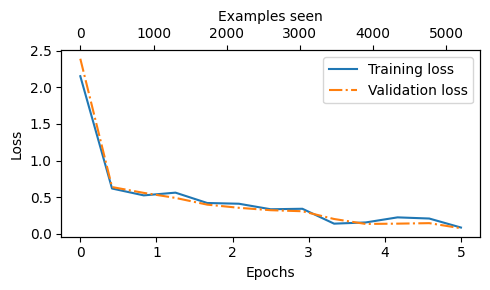

In [83]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- 从上图的下降斜率可以看出，该模型学习效果良好
- 此外，训练损失和验证损失非常接近，表明该模型没有过拟合训练数据的倾向
- 同样，我们可以绘制出如下的准确度图。

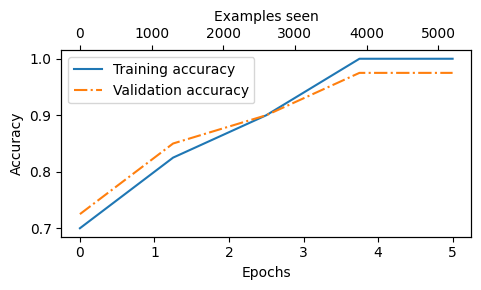

In [84]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- 根据上面的准确率图，我们可以看到，该模型在第 4 和第 5 个训练轮后都达到了相对较高的训练和验证准确率
- 但是，我们必须记住，我们之前在训练函数中指定了 `eval_iter=5`，这意味着我们只评估了训练集和验证集的性能。
- 我们可以按如下方式计算完整数据集的训练集、验证集和测试集性能。

In [88]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- 我们可以看到，训练集和验证集的性能几乎完全相同
- 然而，根据略低的测试集性能，我们可以看出该模型对训练数据以及用于调整某些超参数（例如学习率）的验证数据都存在轻微的过拟合现象。
- 这是正常现象，但可以通过增加模型的 dropout 率（`drop_rate`）或优化器设置中的 `weight_decay` 来进一步缩小这种差距。

### 6.8 使用大语言模型作为垃圾消息分类器

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/18.webp" width=600px>

- 最后，让我们实际应用一下经过微调的 GPT 模型。
- 下面的 `classify_review` 函数实现了与我们之前实现的 `SpamDataset` 类似的预处理数据步骤。
- 然后，该函数返回模型预测的整数类别标签，并返回相应的类别名称

In [89]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

- 让我们通过以下几个例子来尝试一下。

In [90]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [ ]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

- 最后，我们保存模型，以便以后无需重新训练即可再次使用该模型

In [ ]:
torch.save(model.state_dict(), "review_classifier.pth")

- 然后，在新会话中，我们可以按如下方式加载模型

In [98]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

## 总结和要点

- See the [./gpt_class_finetune.py](./gpt_class_finetune.py) script, a self-contained script for classification finetuning
- You can find the exercise solutions in [./exercise-solutions.ipynb](./exercise-solutions.ipynb)
- In addition, interested readers can find an introduction to parameter-efficient training with low-rank adaptation (LoRA) in [appendix E](../../appendix-E)